# ORIGEN — Paso 2: Análisis Exploratorio de Datos (EDA)

**Proyecto:** E-commerce Operations & Supply Chain Analytics · **Base:** `OrigenDB`

**Fuente:** los 6 CSV de `data/raw/` generados en el Paso 1 desde las vistas analíticas
(`vw_PedidosOperaciones`, `vw_TiemposEstados`, `vw_IncidenciasPicking`,
`vw_MovimientosInventario`, `vw_StockHistorico`, `vw_Devoluciones`).

**Herramientas:** `pandas` + `matplotlib` (sin seaborn ni plotly).

Este notebook **solo describe los datos**. No define KPIs, no evalúa cumplimiento de SLA,
no emite recomendaciones de negocio, no escribe CSV ni modifica SQL Server.

| # | Sección |
|---|---|
| 1 | Carga |
| 2 | Calidad de datos |
| 3 | Alcance: Fase 4 vs. heredado de Fase 3 |
| 4 | Análisis de pedidos |
| 5 | Tiempos operativos |
| 6 | Incidencias |
| 7 | Inventario (movimientos y stock histórico) |
| 8 | Devoluciones |
| 9 | Campaña (Cyber Origen) |
| 10 | Conclusiones preliminares |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
%matplotlib inline


def encontrar_raiz(inicio: Path) -> Path:
    """Localiza la raíz del repositorio buscando hacia arriba desde el directorio de trabajo.

    Permite ejecutar el notebook con el kernel iniciado en la raíz del repo o en
    python/eda/, sin usar rutas absolutas de máquina.
    """
    for candidato in [inicio, *inicio.parents]:
        if (candidato / "data" / "raw").is_dir() and (candidato / "sql").is_dir():
            return candidato
    raise FileNotFoundError(f"No se encontró data/raw + sql partiendo de {inicio}")


RAIZ = encontrar_raiz(Path.cwd())
RAW = RAIZ / "data" / "raw"
print("Repositorio:", RAIZ.name)
print("Datos:", RAW.relative_to(RAIZ))

Repositorio: origen-ecommerce-analytics
Datos: data\raw


## 1. Carga

Se leen los 6 CSV con rutas relativas a la raíz del repositorio (resuelta buscando
hacia arriba desde el directorio de trabajo). Por dataset se muestran filas, columnas,
nombres de columnas y tipos de datos.

In [2]:
ARCHIVOS = {
    "pedidos": "pedidos_operaciones.csv",
    "tiempos": "tiempos_estados.csv",
    "incidencias": "incidencias.csv",
    "movimientos": "movimientos.csv",
    "stock": "stock_historico.csv",
    "devoluciones": "devoluciones.csv",
}

datos = {nombre: pd.read_csv(RAW / archivo) for nombre, archivo in ARCHIVOS.items()}

pd.DataFrame(
    [
        {"dataset": nombre, "archivo": archivo, "filas": len(df), "columnas": df.shape[1]}
        for (nombre, archivo), df in zip(ARCHIVOS.items(), datos.values())
    ]
).set_index("dataset")

,archivo,filas,columnas
dataset,,,
pedidos,pedidos_operaciones.csv,58,28
tiempos,tiempos_estados.csv,315,23
incidencias,incidencias.csv,12,30
movimientos,movimientos.csv,116,25
stock,stock_historico.csv,5040,17
devoluciones,devoluciones.csv,6,23


In [3]:
for nombre, df in datos.items():
    print(f"--- {ARCHIVOS[nombre]}: {df.shape[0]} filas x {df.shape[1]} columnas ---")
    print(df.dtypes.to_string(), "\n")

--- pedidos_operaciones.csv: 58 filas x 28 columnas ---
LineaID                int64
PedidoID               int64
ClienteID              int64
NombreCliente            str
SKUID                  int64
CodigoSKU                str
NombreProducto           str
Categoria                str
TiendaID             float64
NombreTienda             str
Ciudad                   str
FechaID                int64
Fecha                    str
Anio                   int64
Mes                    int64
NombreMes                str
EsCampania              bool
NombreCampania           str
Canal                    str
Cantidad               int64
EstadoActual             str
EsFinal                 bool
MotivoCancelacion        str
Cancelada              int64
NIncidencias           int64
TieneIncidencia        int64
TipoIncidencia           str
MotivoIncidencia         str 

--- tiempos_estados.csv: 315 filas x 23 columnas ---
HistorialID          int64
LineaID              int64
PedidoID             in

## 2. Calidad de datos

Para cada dataset: nulos por columna, % de nulos, duplicados, tipos (arriba) y
cardinalidad de las columnas relevantes. **No se elimina ningún dato**: los nulos
se clasifican como válidos por diseño en la tabla siguiente.

In [4]:
calidad = []
for nombre, df in datos.items():
    for col in df.columns:
        calidad.append(
            {
                "dataset": nombre,
                "columna": col,
                "tipo": str(df[col].dtype),
                "nulos": int(df[col].isna().sum()),
                "%nulos": round(100 * df[col].isna().mean(), 1),
                "cardinalidad": int(df[col].nunique(dropna=True)),
            }
        )
calidad = pd.DataFrame(calidad)

print("Columnas CON nulos:")
display(calidad[calidad["nulos"] > 0].sort_values(["dataset", "%nulos"], ascending=[True, False]).reset_index(drop=True))

sin_nulos = [n for n, df in datos.items() if int(df.isna().sum().sum()) == 0]
print("Datasets sin ninguna celda nula:", sin_nulos)

Columnas CON nulos:


,dataset,columna,tipo,nulos,%nulos,cardinalidad
0,incidencias,MovimientoID,float64,10,83.3,2
1,incidencias,AreaEscaladaID,float64,7,58.3,2
2,incidencias,NombreAreaEscalada,str,7,58.3,2
3,incidencias,FechaHoraResolucion,str,3,25.0,3
4,incidencias,DuracionMinutos,float64,3,25.0,3
5,incidencias,LineaID,float64,2,16.7,10
6,incidencias,PedidoID,float64,2,16.7,10
7,incidencias,ClienteID,float64,2,16.7,5
8,incidencias,NombreCliente,str,2,16.7,5
9,incidencias,SKUID,float64,2,16.7,8


Datasets sin ninguna celda nula: ['stock', 'devoluciones']


In [5]:
relevantes = {
    "pedidos": ["PedidoID", "LineaID", "EstadoActual", "MotivoCancelacion", "Canal",
                "NombreTienda", "Categoria", "EsCampania", "NombreCampania", "NombreMes"],
    "tiempos": ["NombreEstado", "EsFinal", "NombreTienda", "Categoria"],
    "incidencias": ["TipoIncidencia", "EstadoResolucion", "NombreArea", "NombreAreaEscalada",
                    "NombreMotivo", "NombreTienda", "NombreMes"],
    "movimientos": ["TipoMovimiento", "Origen", "NombreMotivo", "CodigoSKU", "NombreTienda", "NombreMes"],
    "stock": ["FechaID", "CodigoSKU", "NombreTienda", "Categoria"],
    "devoluciones": ["NombreMotivo", "Categoria", "NombreTienda", "NombreMes"],
}
print("Cardinalidad (valores distintos) de columnas relevantes:")
for nombre, columnas in relevantes.items():
    print(f"  {nombre:13}", {c: int(datos[nombre][c].nunique(dropna=True)) for c in columnas})

Cardinalidad (valores distintos) de columnas relevantes:
  pedidos       {'PedidoID': 51, 'LineaID': 58, 'EstadoActual': 4, 'MotivoCancelacion': 3, 'Canal': 2, 'NombreTienda': 3, 'Categoria': 4, 'EsCampania': 2, 'NombreCampania': 1, 'NombreMes': 4}
  tiempos       {'NombreEstado': 13, 'EsFinal': 2, 'NombreTienda': 3, 'Categoria': 4}
  incidencias   {'TipoIncidencia': 4, 'EstadoResolucion': 4, 'NombreArea': 1, 'NombreAreaEscalada': 2, 'NombreMotivo': 4, 'NombreTienda': 3, 'NombreMes': 4}
  movimientos   {'TipoMovimiento': 5, 'Origen': 6, 'NombreMotivo': 2, 'CodigoSKU': 14, 'NombreTienda': 3, 'NombreMes': 4}
  stock         {'FechaID': 90, 'CodigoSKU': 14, 'NombreTienda': 4, 'Categoria': 4}
  devoluciones  {'NombreMotivo': 3, 'Categoria': 3, 'NombreTienda': 3, 'NombreMes': 2}


In [6]:
claves = {
    "pedidos": "LineaID",
    "tiempos": "HistorialID",
    "incidencias": "IncidenciaID",
    "movimientos": "MovimientoID",
    "devoluciones": "DevolucionID",
}
print("Duplicados y claves:")
for nombre, df in datos.items():
    dup_filas = int(df.duplicated().sum())
    if nombre == "stock":
        dup_clave = int(df.duplicated(["FechaID", "SKUID", "TiendaID"]).sum())
        print(f"  {nombre:13} filas duplicadas={dup_filas} | FechaID+SKUID+TiendaID duplicadas={dup_clave}")
    else:
        clave = claves[nombre]
        dup_clave = int(df[clave].duplicated().sum())
        print(f"  {nombre:13} filas duplicadas={dup_filas} | {clave} duplicadas={dup_clave}")

Duplicados y claves:
  pedidos       filas duplicadas=0 | LineaID duplicadas=0
  tiempos       filas duplicadas=0 | HistorialID duplicadas=0
  incidencias   filas duplicadas=0 | IncidenciaID duplicadas=0
  movimientos   filas duplicadas=0 | MovimientoID duplicadas=0
  stock         filas duplicadas=0 | FechaID+SKUID+TiendaID duplicadas=0
  devoluciones  filas duplicadas=0 | DevolucionID duplicadas=0


### Nulos válidos por diseño (no son errores de calidad)

| Dataset | Columna(s) | Nulos | Por qué es válido |
|---|---|---|---|
| pedidos | `TiendaID`, `NombreTienda`, `Ciudad` | 10 | líneas **Rechazado**: nunca se asignan a tienda (la reserva falló antes) |
| pedidos | `NombreCampania` | 47 | solo se llena en fechas de campaña |
| pedidos | `MotivoCancelacion` | 45 | solo se llena en líneas canceladas |
| pedidos | `TipoIncidencia`, `MotivoIncidencia` | 48 | solo se llena en líneas con incidencia |
| tiempos | `FechaSalida`, `DuracionMinutos` | 58 | el **episodio en curso** de cada línea aún no tiene salida |
| tiempos | `TiendaID` y amigos | 10 | mismas líneas Rechazado |
| incidencias | `LineaID`, `PedidoID` y dimensiones de línea | 2 | **incidencias de recepción del CD**: no existen hasta que se asignan a una línea |
| incidencias | `MovimientoID` | 10 | solo las incidencias de recepción se ligan a un movimiento |
| incidencias | `AreaEscalada` | 7 | incidencias **no escaladas** |
| incidencias | `FechaHoraResolucion`, `DuracionMinutos` | 3 | estados `en_atencion` (2) y `escalada` (1) sin cierre |
| movimientos | `MotivoID` y `NombreMotivo` | 107 | solo los AJUSTE llevan motivo de ajuste |
| movimientos | `CantidadEsperada`, `CantidadRecibida`, `Discrepancia` | 108 | solo aplican a recepciones del CD (8 filas) |
| movimientos | `LineaID`, `PedidoID` | 22 | **movimientos de inventario sin pedido** (configuración inicial, recepciones CD, ajustes) |
| stock, devoluciones | — | 0 | sin nulos |

In [7]:
p = datos["pedidos"]
t = datos["tiempos"]
i = datos["incidencias"]
m = datos["movimientos"]

# 1) TiendaID nulo solo en líneas Rechazado
print("TiendaID nulo, por estado:")
print(p.loc[p["TiendaID"].isna(), "EstadoActual"].value_counts().to_string(), "\n")

# 2) Un episodio abierto (sin salida) por línea
abiertos = t.groupby("LineaID")["FechaSalida"].apply(lambda s: int(s.isna().sum()))
print("Episodios sin salida por línea (esperado: todos 1):")
print(abiertos.value_counts().to_string(), "\n")

# 3) Las incidencias sin línea son exactamente las de recepción
print("Incidencias sin PedidoID:")
print(i.loc[i["PedidoID"].isna(), ["IncidenciaID", "TipoIncidencia", "MovimientoID"]].to_string(index=False), "\n")

# 4) Las columnas de recepción del CD solo están pobladas en ese origen
print("Filas con CantidadEsperada poblada, por origen:")
print(m.loc[m["CantidadEsperada"].notna(), "Origen"].value_counts().to_string())

TiendaID nulo, por estado:
EstadoActual
Rechazado    10 

Episodios sin salida por línea (esperado: todos 1):
FechaSalida
1    58 

Incidencias sin PedidoID:
 IncidenciaID       TipoIncidencia  MovimientoID
         2015 recepcion_incompleta        2082.0
         2016 recepcion_incompleta        2083.0 

Filas con CantidadEsperada poblada, por origen:
Origen
RECEPCION_CD    8


In [8]:
COLUMNAS_FECHA = {
    "pedidos": ["Fecha"],
    "tiempos": ["Fecha", "FechaEntrada", "FechaSalida"],
    "incidencias": ["Fecha", "FechaHoraDeteccion", "FechaHoraResolucion"],
    "movimientos": ["Fecha", "FechaHora"],
    "stock": ["Fecha"],
    "devoluciones": ["Fecha", "FechaDevolucion"],
}
for nombre, columnas in COLUMNAS_FECHA.items():
    for col in columnas:
        datos[nombre][col] = pd.to_datetime(datos[nombre][col])  # solo en memoria

print("Columnas de fecha/hora convertidas a datetime (en memoria; los CSV no se tocan).")
print("Ejemplo tiempos:")
print(datos["tiempos"][["Fecha", "FechaEntrada", "FechaSalida"]].dtypes.to_string())

Columnas de fecha/hora convertidas a datetime (en memoria; los CSV no se tocan).
Ejemplo tiempos:
Fecha           datetime64[us]
FechaEntrada    datetime64[us]
FechaSalida     datetime64[us]


In [9]:
print("Rango de fechas por dataset (dos relojes distintos):\n")
for nombre, col_real in [
    ("pedidos", None),
    ("incidencias", "FechaHoraDeteccion"),
    ("tiempos", "FechaEntrada"),
    ("movimientos", "FechaHora"),
    ("devoluciones", "FechaDevolucion"),
]:
    df = datos[nombre]
    linea = f"  {nombre:13} Fecha (negocio): {df['Fecha'].min():%Y-%m-%d} .. {df['Fecha'].max():%Y-%m-%d}"
    if col_real:
        linea += f" | {col_real}: {df[col_real].min():%Y-%m-%d %H:%M:%S} .. {df[col_real].max():%Y-%m-%d %H:%M:%S}"
    print(linea)

print("\nValores distintos de NombreMes en los CSV (mezcla de idiomas):")
todos_meses = pd.concat([df["NombreMes"] for df in datos.values()])
print(sorted(todos_meses.unique()))
print("=> Se usa Mes (numérico) para cualquier agrupación; NombreMes no es confiable.")

Rango de fechas por dataset (dos relojes distintos):

  pedidos       Fecha (negocio): 2026-01-02 .. 2026-03-30
  incidencias   Fecha (negocio): 2026-01-01 .. 2026-03-19 | FechaHoraDeteccion: 2026-09-29 18:43:57 .. 2026-10-02 02:18:40
  tiempos       Fecha (negocio): 2026-01-02 .. 2026-03-30 | FechaEntrada: 2026-09-29 17:00:35 .. 2026-10-05 13:42:37
  movimientos   Fecha (negocio): 2026-01-01 .. 2026-03-21 | FechaHora: 2026-01-01 00:00:00 .. 2026-10-05 13:42:37
  devoluciones  Fecha (negocio): 2026-01-09 .. 2026-02-22 | FechaDevolucion: 2026-10-02 02:18:40 .. 2026-10-02 02:18:40

Valores distintos de NombreMes en los CSV (mezcla de idiomas):
['Enero', 'February', 'January', 'March']
=> Se usa Mes (numérico) para cualquier agrupación; NombreMes no es confiable.


## 3. Alcance: Fase 4 vs. heredado de Fase 3

Los CSV contienen el escenario del **Bloque 4 / Fase 4** más la línea base heredada de la
Fase 3. Criterio aplicado **por dataset** (el mismo enfoque no sirve para todos):

| Dataset | Criterio | Justificación |
|---|---|---|
| `pedidos`, `tiempos`, `devoluciones` | `PedidoID` entre **100001–100045** → *Fase 4*; entre 990001–990030 → *Heredado Fase 3* | el escenario se declaró con ese rango (45 pedidos; docs/04 §3.2) y los pedidos 990xxx son la línea base previa: docs/04 §2.3 cita las líneas 53, 1054 y 1055 —tres de las seis líneas heredadas— de esos pedidos. En los datos los rangos **no se solapan** y los conteos cuadran (45 y 6 pedidos) |
| `incidencias` | `PedidoID` cuando existe (10 de 12); para las 2 de recepción CD (sin línea ni pedido) se usa `FechaHoraDeteccion >= 2026-10-01` | las recepciones del CD no tienen pedido que las vincule; su detección ocurre durante la ejecución del Bloque 4 (2026-10-02) y la única heredada se detectó el 2026-09-29 (Fase 3) |
| `movimientos` | `PedidoID` cuando existe → Fase 4 / heredado; sin `PedidoID` → **"Global (sin pedido)"** | por diseño hay movimientos de inventario sin pedido (configuración inicial, recepciones CD, ajustes): no pertenecen a ninguno de los dos grupos y se reportan aparte, con su hora real de ejecución |
| `stock_historico` | **No aplica** | es una serie derivada del ledger por `FechaID` sin vínculo a pedidos: se analiza completa |

No se borra ningún registro: se agrega una columna `Alcance`.

In [10]:
F4_MIN, F4_MAX = 100001, 100045


def etiquetar_pedido(pedido_id):
    """Fase 4 si el pedido cae en el rango declarado del escenario; si no, heredado."""
    if pd.isna(pedido_id):
        return None
    return "Fase 4" if F4_MIN <= pedido_id <= F4_MAX else "Heredado Fase 3"


# Pedidos, tiempos y devoluciones: el PedidoID está en la fila.
p["Alcance"] = p["PedidoID"].map(etiquetar_pedido)
t["Alcance"] = t["PedidoID"].map(etiquetar_pedido)
datos["devoluciones"]["Alcance"] = datos["devoluciones"]["PedidoID"].map(etiquetar_pedido)

# Incidencias: PedidoID directo; las de recepción CD (nulas) se resuelven por fecha de deteccion.
i["Alcance"] = i["PedidoID"].map(etiquetar_pedido)
sin_pedido = i["Alcance"].isna()
i.loc[sin_pedido, "Alcance"] = (
    i.loc[sin_pedido, "FechaHoraDeteccion"]
    .ge(pd.Timestamp("2026-10-01"))
    .map({True: "Fase 4", False: "Heredado Fase 3"})
)

# Movimientos: tercer grupo para los que no tienen pedido.
m["Alcance"] = m["PedidoID"].map(etiquetar_pedido).fillna("Global (sin pedido)")

print("Etiquetas aplicadas. Ejemplo incidencias sin PedidoID:")
print(i.loc[sin_pedido, ["IncidenciaID", "TipoIncidencia", "FechaHoraDeteccion", "Alcance"]].to_string(index=False))

Etiquetas aplicadas. Ejemplo incidencias sin PedidoID:
 IncidenciaID       TipoIncidencia  FechaHoraDeteccion Alcance
         2015 recepcion_incompleta 2026-10-02 02:18:40  Fase 4
         2016 recepcion_incompleta 2026-10-02 02:18:40  Fase 4


In [11]:
print("Separación verificada en los datos (rangos de PedidoID por alcance):")
print(p.groupby("Alcance")["PedidoID"].agg(["min", "max", "nunique"]).to_string(), "\n")

print("Movimientos sin pedido, por origen y hora real de ejecución:")
g = m[m["Alcance"] == "Global (sin pedido)"]
print(g.groupby(["TipoMovimiento", "Origen"])["FechaHora"].agg(["count", "min", "max"]).to_string())

Separación verificada en los datos (rangos de PedidoID por alcance):
                    min     max  nunique
Alcance                                 
Fase 4           100001  100045       45
Heredado Fase 3  990001  990030        6 

Movimientos sin pedido, por origen y hora real de ejecución:
                                      count                 min                 max
TipoMovimiento Origen                                                              
AJUSTE         CANCELACION                3 2026-09-30 02:20:25 2026-10-05 13:42:37
               CONTEO_FISICO              6 2026-10-02 02:18:40 2026-10-02 02:18:40
INGRESO        CONFIGURACION_INICIAL      5 2026-01-01 00:00:00 2026-01-01 00:00:00
               RECEPCION_CD               8 2026-10-02 02:18:40 2026-10-02 02:18:40


In [12]:
alcance = pd.DataFrame(
    {
        "registros": pd.concat(
            {
                "pedidos (líneas)": p["Alcance"],
                "episodios": t["Alcance"],
                "incidencias": i["Alcance"],
                "movimientos": m["Alcance"],
                "devoluciones": datos["devoluciones"]["Alcance"],
            }
        ).value_counts()
    }
).fillna(0).astype(int)
print("Registros por alcance y dataset:")
display(alcance)

print("\nPedidos y líneas por alcance:")
display(p.groupby("Alcance").agg(pedidos=("PedidoID", "nunique"), lineas=("LineaID", "size"), unidades=("Cantidad", "sum")))

print("\nstock_historico: alcance no aplica (sin vínculo a pedido) —",
      len(datos["stock"]), "filas analizadas completas.")

Registros por alcance y dataset:


,registros
Alcance,
Fase 4,443
Heredado Fase 3,42
Global (sin pedido),22



Pedidos y líneas por alcance:


,pedidos,lineas,unidades
Alcance,,,
Fase 4,45,52,87
Heredado Fase 3,6,6,8



stock_historico: alcance no aplica (sin vínculo a pedido) — 5040 filas analizadas completas.


## 4. Análisis de pedidos

Sobre las **52 líneas / 45 pedidos de Fase 4** (`Alcance == "Fase 4"`).

In [13]:
f4 = p[p["Alcance"] == "Fase 4"].copy()

resumen_f4 = {
    "pedidos": f4["PedidoID"].nunique(),
    "líneas": len(f4),
    "unidades": int(f4["Cantidad"].sum()),
    "clientes": f4["ClienteID"].nunique(),
    "tiendas asignadas": int(f4["TiendaID"].notna().sum()),
    "SKU distintos": f4["SKUID"].nunique(),
    "categorías": f4["Categoria"].nunique(),
    "fechas (negocio)": f"{f4['Fecha'].min():%Y-%m-%d} .. {f4['Fecha'].max():%Y-%m-%d}",
}
for k, v in resumen_f4.items():
    print(f"  {k:20} {v}")

  pedidos              45
  líneas               52
  unidades             87
  clientes             6
  tiendas asignadas    44
  SKU distintos        14
  categorías           4
  fechas (negocio)     2026-01-02 .. 2026-03-30


,líneas,% líneas
EstadoActual,,
Completado,31,59.6
Cancelado,11,21.2
Rechazado,8,15.4
Incidencia de picking,2,3.8
Disponible para recojo,0,0.0


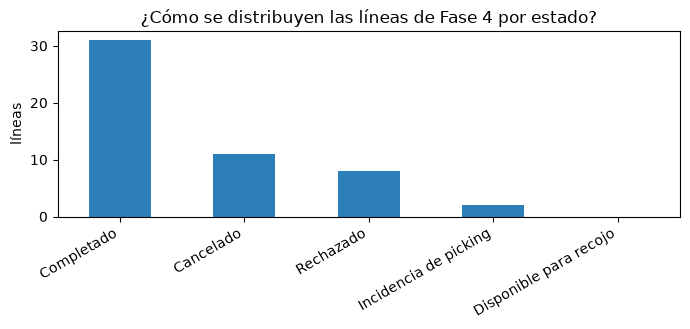

In [14]:
orden = ["Completado", "Cancelado", "Rechazado", "Incidencia de picking", "Disponible para recojo"]
conteo = f4["EstadoActual"].value_counts().reindex(orden, fill_value=0)
display(conteo.rename("líneas").to_frame().assign(**{"% líneas": (100 * conteo / len(f4)).round(1)}))

ax = conteo.plot(kind="bar", color="#2c7fb8", figsize=(7, 3.4), title="¿Cómo se distribuyen las líneas de Fase 4 por estado?")
ax.set_xlabel("")
ax.set_ylabel("líneas")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [15]:
print("Líneas por canal:")
display(f4["Canal"].value_counts().rename("líneas").to_frame())
print("Pedidos por canal:")
display(f4.groupby("Canal")["PedidoID"].nunique().rename("pedidos").to_frame())

print("Líneas por tienda (las Rechazado no tienen tienda):")
display(f4["NombreTienda"].value_counts(dropna=False).rename("líneas").to_frame())

print("Líneas por categoría:")
display(f4["Categoria"].value_counts().rename("líneas").to_frame())

Líneas por canal:

,líneas
Canal,
recojo,31
despacho,21


Pedidos por canal:


,pedidos
Canal,
despacho,18
recojo,27


Líneas por tienda (las Rechazado no tienen tienda):


,líneas
NombreTienda,
Jockey Plaza,16
Real Plaza Arequipa,16
Mall Aventura Trujillo,12
NaN,8


Líneas por categoría:


,líneas
Categoria,
Ropa,27
Perfumería,9
Calzado,9
Accesorios,7


Líneas canceladas: 11 de 52


,líneas
MotivoCancelacion,
voluntaria,6
incidencia_picking,3
vencimiento,2


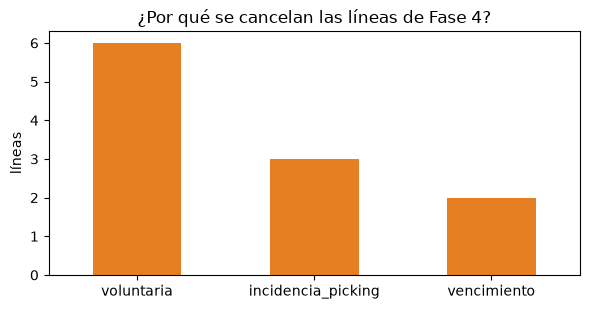

In [16]:
canceladas = f4[f4["MotivoCancelacion"].notna()]
print(f"Líneas canceladas: {len(canceladas)} de {len(f4)}")
display(canceladas["MotivoCancelacion"].value_counts().rename("líneas").to_frame())

ax = canceladas["MotivoCancelacion"].value_counts().plot(
    kind="bar", color="#e67e22", figsize=(6, 3.2),
    title="¿Por qué se cancelan las líneas de Fase 4?",
)
ax.set_xlabel("")
ax.set_ylabel("líneas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
print("Rango de fechas de negocio y reparto por mes (usando Mes numérico):")
display(f4.groupby("Mes").agg(lineas=("LineaID", "size"), pedidos=("PedidoID", "nunique"), fechas=("FechaID", "nunique")))

print("\nCampaña vs. no campaña (líneas y pedidos de Fase 4):")
display(f4.groupby("EsCampania").agg(lineas=("LineaID", "size"), pedidos=("PedidoID", "nunique")))

print("\nDistribución de estados dentro de cada grupo de campaña (% por fila):")
display(pd.crosstab(f4["EsCampania"], f4["EstadoActual"], normalize="index").round(2))

Rango de fechas de negocio y reparto por mes (usando Mes numérico):


,lineas,pedidos,fechas
Mes,,,
1,14,12,12
2,13,11,11
3,25,22,20



Campaña vs. no campaña (líneas y pedidos de Fase 4):


,lineas,pedidos
EsCampania,,
False,41,36
True,11,9



Distribución de estados dentro de cada grupo de campaña (% por fila):


EstadoActual,Cancelado,Completado,Incidencia de picking,Rechazado
EsCampania,,,,
False,0.15,0.61,0.05,0.2
True,0.45,0.55,0.00,0.0


## 5. Tiempos operativos

Exploración de `vw_TiemposEstados`: episodios por estado y duraciones.

> **No se define SLA ni se afirma "cumple/incumple"**: aquí solo se describe el
> comportamiento observado. Las metas de SLA no existen todavía en el proyecto.

In [18]:
t4 = t[t["Alcance"] == "Fase 4"]

episodios = pd.DataFrame({
    "episodios": t4["NombreEstado"].value_counts(),
    "abiertos (sin salida)": t4.loc[t4["FechaSalida"].isna(), "NombreEstado"].value_counts(),
}).fillna(0).astype(int)
display(episodios)

print(f"Total Fase 4: {len(t4)} episodios | abiertos: {int(t4['FechaSalida'].isna().sum())} | "
      f"cerrados: {int(t4['FechaSalida'].notna().sum())}")
print(f"Episodios abiertos en todo el dataset: {int(t['FechaSalida'].isna().sum())} "
      f"(= una línea abierta por cada una de las {len(p)} líneas)")

,episodios,abiertos (sin salida)
NombreEstado,,
Asignado a picking,42,0
Cancelado,11,11
Completado,31,31
Disponible para recojo,21,0
Empaquetado,33,0
En tránsito,12,0
Entregado,12,0
Incidencia de picking,9,2
Pedido creado,44,0


Total Fase 4: 288 episodios | abiertos: 52 | cerrados: 236
Episodios abiertos en todo el dataset: 58 (= una línea abierta por cada una de las 58 líneas)


In [19]:
dur = t4.groupby("NombreEstado")["DuracionMinutos"].agg(
    n="count", mediana="median", media="mean", minimo="min", maximo="max"
).round(1).sort_values("n", ascending=False)
display(dur)

d = t4["DuracionMinutos"].dropna()
print(f"Episodios con duración medida: {len(d)} | con más de 0 min: {int((d > 0).sum())} | "
      f"mediana: {d.median():.0f} min | máximo: {d.max():.0f} min")

,n,mediana,media,minimo,maximo
NombreEstado,,,,,
Pedido creado,44,0.0,0.0,0.0,0.0
Picking en proceso,44,0.0,0.0,0.0,0.0
Asignado a picking,42,0.0,0.0,0.0,0.0
Empaquetado,33,0.0,0.0,0.0,0.0
Disponible para recojo,21,0.0,476.6,0.0,5004.0
Recojo por cliente,19,0.0,0.0,0.0,0.0
En tránsito,12,0.0,0.0,0.0,0.0
Entregado,12,0.0,0.0,0.0,0.0
Incidencia de picking,7,5004.0,2859.4,0.0,5004.0


Episodios con duración medida: 236 | con más de 0 min: 6 | mediana: 0 min | máximo: 5004 min


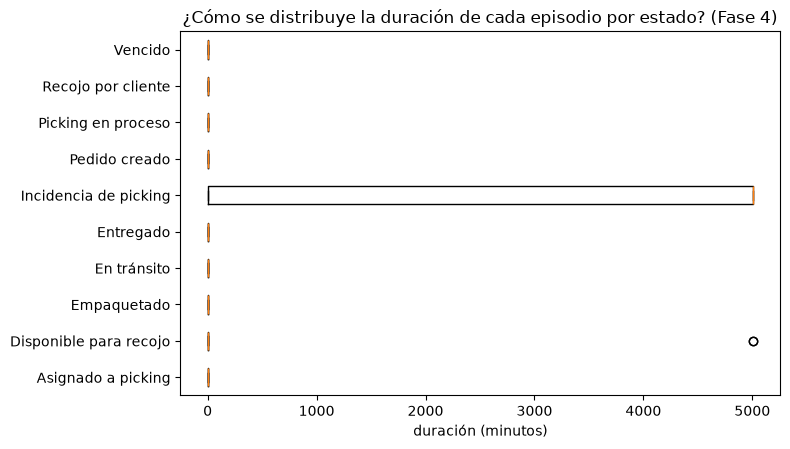

Episodios con las duraciones más altas:


,PedidoID,NombreEstado,FechaEntrada,FechaSalida,DuracionMinutos
131,100014,Incidencia de picking,2026-10-02 02:18:40,2026-10-05 13:42:37,5004.0
136,100015,Incidencia de picking,2026-10-02 02:18:40,2026-10-05 13:42:37,5004.0
212,100027,Incidencia de picking,2026-10-02 02:18:40,2026-10-05 13:42:37,5004.0
286,100038,Disponible para recojo,2026-10-02 02:18:40,2026-10-05 13:42:37,5004.0
293,100039,Disponible para recojo,2026-10-02 02:18:40,2026-10-05 13:42:37,5004.0


In [20]:
con_datos = [
    e for e in sorted(t4["NombreEstado"].unique())
    if t4.loc[t4["NombreEstado"] == e, "DuracionMinutos"].notna().any()
]
grupos = [t4.loc[t4["NombreEstado"] == e, "DuracionMinutos"].dropna().values for e in con_datos]

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.boxplot(grupos, orientation="horizontal")
ax.set_yticks(range(1, len(con_datos) + 1))
ax.set_yticklabels(con_datos)
ax.set_xlabel("duración (minutos)")
ax.set_title("¿Cómo se distribuye la duración de cada episodio por estado? (Fase 4)")
plt.tight_layout()
plt.show()

print("Episodios con las duraciones más altas:")
display(t4.nlargest(5, "DuracionMinutos")[["PedidoID", "NombreEstado", "FechaEntrada", "FechaSalida", "DuracionMinutos"]])

**Lectura descriptiva (sin SLA):**

- La mayoría de los episodios cierra en **0 minutos**: las operaciones del escenario se
  ejecutan en ráfaga, por lo que la duración al minuto queda en cero.
- Las duraciones no nulas se concentran en **`Disponible para recojo`** (espera del cliente)
  e **`Incidencia de picking`** (tiempo de resolución).
- Los extremos observados son **5.004 minutos (≈ 3,5 días)**: corresponden a esperas que
  cruzan la ventana entre la sesión 1 (2026-10-02) y la sesión 2 (2026-10-05) del escenario.
- Los estados finales (`Completado`, `Cancelado`, `Rechazado`) tienen el episodio abierto,
  por eso su duración es nula: el tiempo total de vida de esas líneas se calcula en la
  fase de KPIs, no aquí.

## 6. Incidencias

Distribución por tipo, estado de resolución, tienda y área; relación con los pedidos.
Solo se describen conteos: **no se infieren causalidades**.

In [21]:
i4 = i[i["Alcance"] == "Fase 4"]

print("Por alcance:")
display(i["Alcance"].value_counts().rename("incidencias").to_frame())

print("Fase 4 — tipo:")
display(i4["TipoIncidencia"].value_counts().rename("incidencias").to_frame())
print("Fase 4 — estado de resolución:")
display(i4["EstadoResolucion"].value_counts().rename("incidencias").to_frame())
print("Fase 4 — tipo x estado:")
display(pd.crosstab(i4["TipoIncidencia"], i4["EstadoResolucion"], margins=True))

Por alcance:


,incidencias
Alcance,
Fase 4,11
Heredado Fase 3,1


Fase 4 — tipo:


,incidencias
TipoIncidencia,
no_encontrado,4
cantidad_insuficiente,3
dañado,2
recepcion_incompleta,2


Fase 4 — estado de resolución:


,incidencias
EstadoResolucion,
resuelta,5
no_resuelta,3
en_atencion,2
escalada,1


Fase 4 — tipo x estado:


EstadoResolucion,en_atencion,escalada,no_resuelta,resuelta,All
TipoIncidencia,,,,,
cantidad_insuficiente,1,0,1,1,3
dañado,0,0,1,1,2
no_encontrado,1,0,1,2,4
recepcion_incompleta,0,1,0,1,2
All,2,1,3,5,11


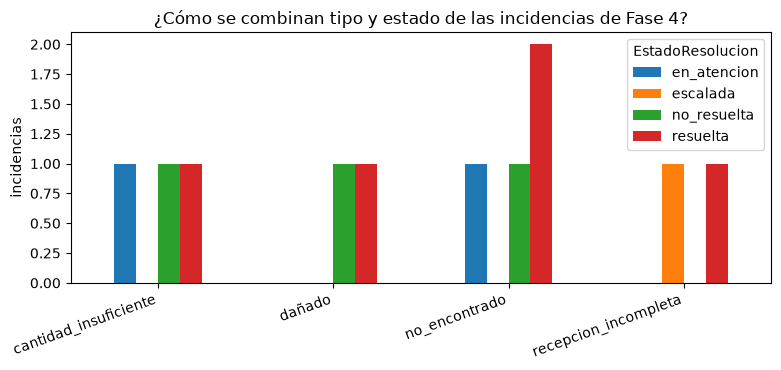

In [22]:
ct = pd.crosstab(i4["TipoIncidencia"], i4["EstadoResolucion"])
ax = ct.plot(kind="bar", figsize=(8, 3.8), title="¿Cómo se combinan tipo y estado de las incidencias de Fase 4?")
ax.set_xlabel("")
ax.set_ylabel("incidencias")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [23]:
print("Fase 4 — por tienda x tipo:")
display(pd.crosstab(i4["NombreTienda"], i4["TipoIncidencia"], margins=True))

print("Área de escalamiento (12 incidencias, todos los alcances):")
display(i["NombreAreaEscalada"].value_counts(dropna=False).rename("incidencias").to_frame())

print("Relación con el pedido (estado del pedido al cierre):")
ped_estado = p.drop_duplicates("PedidoID")[["PedidoID", "EstadoActual", "Canal"]]
junta = i4.merge(ped_estado, on="PedidoID", how="left")
display(pd.crosstab(junta["TipoIncidencia"], junta["EstadoActual"].fillna("(sin línea: recepción CD)"), margins=True))

Fase 4 — por tienda x tipo:


TipoIncidencia,cantidad_insuficiente,dañado,no_encontrado,All
NombreTienda,,,,
Jockey Plaza,1,1,1,3
Mall Aventura Trujillo,1,0,2,3
Real Plaza Arequipa,1,1,1,3
All,3,2,4,9


Área de escalamiento (12 incidencias, todos los alcances):


,incidencias
NombreAreaEscalada,
NaN,7
Operaciones E-commerce,4
Abastecimiento,1


Relación con el pedido (estado del pedido al cierre):


EstadoActual,(sin línea: recepción CD),Cancelado,Completado,Incidencia de picking,All
TipoIncidencia,,,,,
cantidad_insuficiente,0,1,2,0,3
dañado,0,0,2,0,2
no_encontrado,0,1,2,1,4
recepcion_incompleta,2,0,0,0,2
All,2,2,6,1,11


In [24]:
print("Duración de resolución (solo tiene valor quien ya cerró):")
print(i["DuracionMinutos"].describe().round(1).to_string())

print("\nIncidencias por estado y si tienen fecha de resolución:")
display(i.groupby("EstadoResolucion").agg(
    incidencias=("IncidenciaID", "size"),
    con_fecha_resolucion=("FechaHoraResolucion", "count"),
    minutos_promedio=("DuracionMinutos", "mean"),
).round(1))

camp = set(p.loc[p["EsCampania"], "FechaID"])
print(f"\nIncidencias en fechas de campaña: {int(i4['FechaID'].isin(camp).sum())} de {len(i4)} (Fase 4)")

Duración de resolución (solo tiene valor quien ya cerró):
count       9.0
mean     2224.6
std      2636.8
min         0.0
25%         0.0
50%         5.0
75%      5004.0
max      5004.0

Incidencias por estado y si tienen fecha de resolución:


,incidencias,con_fecha_resolucion,minutos_promedio
EstadoResolucion,,,
en_atencion,2,0,NaN
escalada,1,0,NaN
no_resuelta,3,3,5004.0
resuelta,6,6,834.8



Incidencias en fechas de campaña: 3 de 11 (Fase 4)


## 7. Inventario

### 7.1 Movimientos (`vw_MovimientosInventario`)

Semántica de `Cantidad` según el trigger de stock (los signos están almacenados en el dato):

| Tipo | Efecto en `StockSistema` | Efecto en `StockReservado` | Signo en `Cantidad` |
|---|---|---|---|
| `INGRESO` | + | — | positivo |
| `RESERVA` | — | + | positivo |
| `LIBERACION_RESERVA` | — | − | negativo |
| `DESCUENTO_DEFINITIVO` | − | − | negativo |
| `AJUSTE` | ± | — | según corresponda |

In [25]:
print("Movimientos por tipo x alcance:")
display(pd.crosstab(m["TipoMovimiento"], m["Alcance"], margins=True))

print("Suma de Cantidad por tipo (efecto neto almacenado):")
display(m.groupby("TipoMovimiento")["Cantidad"].agg(["count", "sum", "min", "max"]))

Movimientos por tipo x alcance:


Alcance,Fase 4,Global (sin pedido),Heredado Fase 3,All
TipoMovimiento,,,,
AJUSTE,0,9,0,9
DESCUENTO_DEFINITIVO,33,0,3,36
INGRESO,0,13,0,13
LIBERACION_RESERVA,9,0,1,10
RESERVA,44,0,4,48
All,86,22,8,116


Suma de Cantidad por tipo (efecto neto almacenado):


,count,sum,min,max
TipoMovimiento,,,,
AJUSTE,9,7,-2,3
DESCUENTO_DEFINITIVO,36,-57,-4,-1
INGRESO,13,97,1,14
LIBERACION_RESERVA,10,-12,-3,-1
RESERVA,48,71,1,4


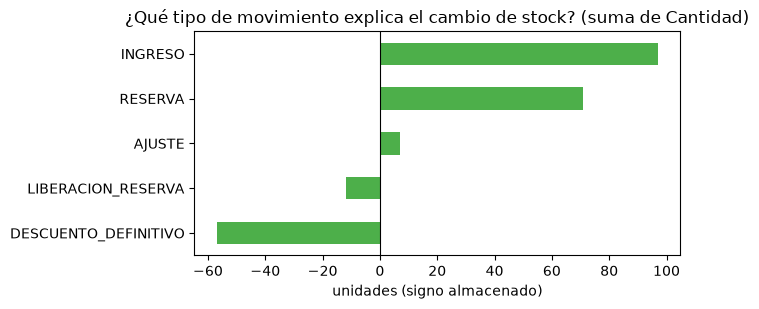

Reconstrucción desde movimientos vs. stock al cierre del escenario:
  StockSistema   movimientos=  47 | último día=  47
  StockReservado movimientos=   2 | último día=   2
  StockDisponible movimientos=  45 | último día=  45


In [26]:
neto = m.groupby("TipoMovimiento")["Cantidad"].sum().sort_values()
ax = neto.plot(kind="barh", color="#4daf4a", figsize=(7, 3.2),
               title="¿Qué tipo de movimiento explica el cambio de stock? (suma de Cantidad)")
ax.set_xlabel("unidades (signo almacenado)")
ax.set_ylabel("")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

# Coherencia: el ledger debe explicar el stock del último día.
s = datos["stock"]
ultimo = s[s["FechaID"] == s["FechaID"].max()]
sis_mov = m.loc[m["TipoMovimiento"].isin(["INGRESO", "AJUSTE", "DESCUENTO_DEFINITIVO"]), "Cantidad"].sum()
res_mov = m.loc[m["TipoMovimiento"].isin(["RESERVA", "LIBERACION_RESERVA", "DESCUENTO_DEFINITIVO"]), "Cantidad"].sum()
print("Reconstrucción desde movimientos vs. stock al cierre del escenario:")
print(f"  StockSistema   movimientos={sis_mov:>4} | último día={int(ultimo['StockSistema'].sum()):>4}")
print(f"  StockReservado movimientos={res_mov:>4} | último día={int(ultimo['StockReservado'].sum()):>4}")
print(f"  StockDisponible movimientos={sis_mov - res_mov:>4} | último día={int(ultimo['StockDisponible'].sum()):>4}")

### 7.2 Stock histórico (`vw_StockHistorico`)

Serie diaria `SKU × Tienda × Fecha` (14 SKU × 4 tiendas × 90 días = 5.040 filas).

Invariantes de calidad del stock:
  StockSistema < 0:  0
  StockReservado < 0: 0
  StockDisponible < 0: 0
  StockReservado > StockSistema: 0

Pico de stock total: 99 u. | cierre: 47 u. | días con stock total 0: 0


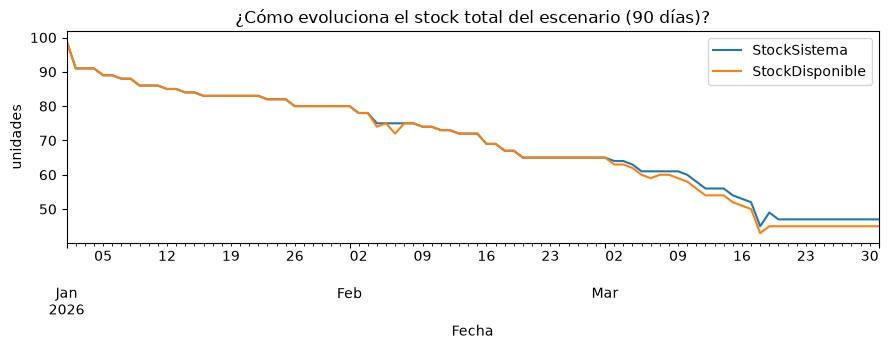

In [27]:
print("Invariantes de calidad del stock:")
print(f"  StockSistema < 0:  {int((s['StockSistema'] < 0).sum())}")
print(f"  StockReservado < 0: {int((s['StockReservado'] < 0).sum())}")
print(f"  StockDisponible < 0: {int((s['StockDisponible'] < 0).sum())}")
print(f"  StockReservado > StockSistema: {int((s['StockReservado'] > s['StockSistema']).sum())}")

evolucion = s.groupby("Fecha")[["StockSistema", "StockDisponible"]].sum()
print(f"\nPico de stock total: {int(evolucion['StockSistema'].max())} u. | "
      f"cierre: {int(evolucion['StockSistema'].iloc[-1])} u. | "
      f"días con stock total 0: {int((evolucion['StockSistema'] == 0).sum())}")

ax = evolucion.plot(figsize=(9, 3.6), title="¿Cómo evoluciona el stock total del escenario (90 días)?")
ax.set_ylabel("unidades")
plt.tight_layout()
plt.show()

Combinaciones con stock al cierre: 12 de 56


,combinacion,StockSistema,StockReservado,StockDisponible
0,A20002 @ Mall Aventura Trujillo,1,0,1
1,A10003 @ Jockey Plaza,2,0,2
2,A30001 @ Real Plaza Arequipa,2,0,2
3,A50001 @ Real Plaza Arequipa,2,1,1
4,A40003 @ Jockey Plaza,3,0,3
5,A20001 @ Jockey Plaza,3,0,3
6,A60001 @ Jockey Plaza,3,0,3
7,A50002 @ Jockey Plaza,4,0,4
8,A60002 @ Mall Aventura Trujillo,4,1,3
9,A40002 @ Mall Aventura Trujillo,6,0,6


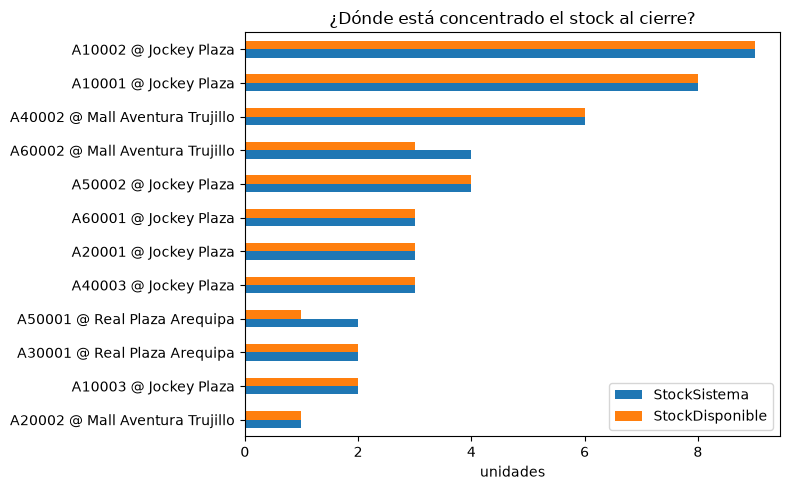

In [28]:
con_stock = ultimo[ultimo["StockSistema"] > 0].copy()
con_stock["combinacion"] = con_stock["CodigoSKU"] + " @ " + con_stock["NombreTienda"]
con_stock = con_stock.sort_values("StockSistema", ascending=True)
print(f"Combinaciones con stock al cierre: {len(con_stock)} de {len(ultimo)}")
display(con_stock[["combinacion", "StockSistema", "StockReservado", "StockDisponible"]].reset_index(drop=True))

ax = con_stock.plot(x="combinacion", y=["StockSistema", "StockDisponible"], kind="barh", figsize=(8, 5),
                    title="¿Dónde está concentrado el stock al cierre?")
ax.set_xlabel("unidades")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [29]:
por_combo = (
    s.sort_values("FechaID")
    .groupby(["CodigoSKU", "NombreTienda"])
    .agg(
        dias_con_stock=("StockSistema", lambda x: int((x > 0).sum())),
        stock_max=("StockSistema", "max"),
        stock_final=("StockSistema", "last"),
        disp_min=("StockDisponible", "min"),
    )
)
sin_abastecer = int((por_combo["stock_max"] == 0).sum())
agotados = por_combo[(por_combo["stock_max"] > 0) & (por_combo["stock_final"] == 0)]
print(f"Combinaciones SKU×Tienda: {len(por_combo)}")
print(f"  - sin stock en ningún día (nunca abastecidas): {sin_abastecer}")
print(f"  - con stock previo que cierran en 0: {len(agotados)}")
print("\nDetalle de las que cierran en 0 (NO implica quiebre: no hay demanda insatisfecha "
      "asociada en los datos; los rechazados no tienen tienda):")
display(agotados)

print("\nMayores cambios diarios de StockSistema (|Δ| >= 3):")
bruscos = s[s["MovimientoStockSistema"].abs() >= 3][
    ["Fecha", "CodigoSKU", "NombreTienda", "MovimientoStockSistema", "StockSistema"]
].head(12)
display(bruscos.reset_index(drop=True))
print("(Los mayores son la carga inicial del 2026-01-01.)")

Combinaciones SKU×Tienda: 56
  - sin stock en ningún día (nunca abastecidas): 41
  - con stock previo que cierran en 0: 3

Detalle de las que cierran en 0 (NO implica quiebre: no hay demanda insatisfecha asociada en los datos; los rechazados no tienen tienda):


,,dias_con_stock,stock_max,stock_final,disp_min
CodigoSKU,NombreTienda,,,,
A10001,Real Plaza Arequipa,62,11,0,0
A30002,Real Plaza Arequipa,22,1,0,0
A40001,Mall Aventura Trujillo,50,2,0,0



Mayores cambios diarios de StockSistema (|Δ| >= 3):


,Fecha,CodigoSKU,NombreTienda,MovimientoStockSistema,StockSistema
0,2026-01-01,A10001,Jockey Plaza,10,10
1,2026-01-01,A10001,Real Plaza Arequipa,11,11
2,2026-02-04,A10001,Real Plaza Arequipa,-3,7
3,2026-02-16,A10001,Real Plaza Arequipa,-3,3
4,2026-01-01,A10002,Jockey Plaza,14,14
5,2026-01-01,A20001,Jockey Plaza,11,11
6,2026-01-02,A20001,Jockey Plaza,-4,7
7,2026-03-18,A20001,Jockey Plaza,-3,2
8,2026-01-01,A30001,Real Plaza Arequipa,3,3
9,2026-01-01,A40002,Mall Aventura Trujillo,11,11


(Los mayores son la carga inicial del 2026-01-01.)


## 8. Devoluciones

Solo **6 registros**: todo es descriptivo, sin conclusiones estadísticas.

In [30]:
d = datos["devoluciones"]
display(d[["DevolucionID", "PedidoID", "Alcance", "NombreTienda", "Categoria",
           "NombreMotivo", "Fecha", "FechaDevolucion"]])

print("Motivos:")
display(d["NombreMotivo"].value_counts().rename("devoluciones").to_frame())
print("Categorías:")
display(d["Categoria"].value_counts().rename("devoluciones").to_frame())
print("Tiendas:")
display(d["NombreTienda"].value_counts().rename("devoluciones").to_frame())

,DevolucionID,PedidoID,Alcance,NombreTienda,Categoria,NombreMotivo,Fecha,FechaDevolucion
0,1002,100003,Fase 4,Jockey Plaza,Ropa,talla_incorrecta,2026-01-09,2026-10-02 02:18:40
1,1003,100006,Fase 4,Jockey Plaza,Perfumería,talla_incorrecta,2026-01-17,2026-10-02 02:18:40
2,1004,100016,Fase 4,Jockey Plaza,Ropa,producto_dañado,2026-02-14,2026-10-02 02:18:40
3,1005,100017,Fase 4,Real Plaza Arequipa,Ropa,no_cumple_expectativa,2026-02-15,2026-10-02 02:18:40
4,1006,100019,Fase 4,Real Plaza Arequipa,Ropa,no_cumple_expectativa,2026-02-18,2026-10-02 02:18:40
5,1007,100021,Fase 4,Mall Aventura Trujillo,Calzado,producto_dañado,2026-02-22,2026-10-02 02:18:40


Motivos:


,devoluciones
NombreMotivo,
talla_incorrecta,2
producto_dañado,2
no_cumple_expectativa,2


Categorías:


,devoluciones
Categoria,
Ropa,4
Perfumería,1
Calzado,1


Tiendas:


,devoluciones
NombreTienda,
Jockey Plaza,3
Real Plaza Arequipa,2
Mall Aventura Trujillo,1


In [31]:
print(f"Fechas de negocio de los pedidos: {d['Fecha'].min():%Y-%m-%d} .. {d['Fecha'].max():%Y-%m-%d}")
print(f"Marca de registro (FechaDevolucion): {d['FechaDevolucion'].nunique()} valor(es) distinto(s) -> "
      f"{d['FechaDevolucion'].min():%Y-%m-%d %H:%M:%S}")
print("\nLas dos columnas viven en relojes distintos (fecha de negocio vs. hora real de ejecución),")
print("por lo que NO se calcula 'días hasta la devolución': el resultado sería un artefacto de reloj.")

Fechas de negocio de los pedidos: 2026-01-09 .. 2026-02-22
Marca de registro (FechaDevolucion): 1 valor(es) distinto(s) -> 2026-10-02 02:18:40

Las dos columnas viven en relojes distintos (fecha de negocio vs. hora real de ejecución),
por lo que NO se calcula 'días hasta la devolución': el resultado sería un artefacto de reloj.


## 9. Campaña (Cyber Origen)

Comparación **descriptiva** entre fechas de campaña y el resto. Las fechas de campaña se
leen de los propios datos (`EsCampania`). **No se afirma causalidad** (y el tamaño de
muestra es pequeño).

In [32]:
camp = sorted(p.loc[p["EsCampania"], "FechaID"].unique())
print(f"Fechas de campaña en los datos: {camp[0]} .. {camp[-1]} ({len(camp)} días)")

print("\nFase 4 — líneas y pedidos:")
display(f4.groupby("EsCampania").agg(lineas=("LineaID", "size"), pedidos=("PedidoID", "nunique")))

print("\nFase 4 — distribución de estados por grupo (% por fila):")
display(pd.crosstab(f4["EsCampania"], f4["EstadoActual"], normalize="index").round(2))

Fechas de campaña en los datos: 20260315 .. 20260321 (7 días)

Fase 4 — líneas y pedidos:


,lineas,pedidos
EsCampania,,
False,41,36
True,11,9



Fase 4 — distribución de estados por grupo (% por fila):


EstadoActual,Cancelado,Completado,Incidencia de picking,Rechazado
EsCampania,,,,
False,0.15,0.61,0.05,0.2
True,0.45,0.55,0.00,0.0


In [33]:
print("Incidencias de Fase 4 en fechas de campaña:",
      int(i4["FechaID"].isin(camp).sum()), "de", len(i4))

mov_camp = m.assign(EnCampania=m["FechaID"].isin(camp))
print("\nMovimientos en fechas de campaña:")
display(mov_camp.groupby("EnCampania").agg(movimientos=("MovimientoID", "size"), unidades=("Cantidad", "sum")))

t4_camp = t4.assign(EnCampania=t4["FechaID"].isin(camp))
print("\nDuración de episodios (Fase 4) por grupo de campaña:")
display(t4_camp.groupby("EnCampania")["DuracionMinutos"].agg(
    episodios="count", con_duracion=lambda x: int(x.notna().sum()), mediana="median", maximo="max"
).round(1))

print("\nCancelaciones de Fase 4 en fechas de campaña:",
      int(f4.loc[f4["EsCampania"] & f4["MotivoCancelacion"].notna()].shape[0]),
      "de", int(f4["MotivoCancelacion"].notna().sum()), "líneas canceladas.")

Incidencias de Fase 4 en fechas de campaña: 3 de 11

Movimientos en fechas de campaña:


,movimientos,unidades
EnCampania,,
False,92,102
True,24,4



Duración de episodios (Fase 4) por grupo de campaña:


,episodios,con_duracion,mediana,maximo
EnCampania,,,,
False,176,176,0.0,5004.0
True,60,60,0.0,5004.0



Cancelaciones de Fase 4 en fechas de campaña: 5 de 11 líneas canceladas.


## 10. Conclusiones preliminares

Solo hallazgos respaldados por los datos de este notebook. **No son recomendaciones de
negocio** ni un catálogo de KPIs.

### Observaciones

1. **Alcance separable sin solapamiento.** 52 líneas / 45 pedidos de Fase 4 vs. 6 líneas /
   6 pedidos heredados; 11 incidencias de Fase 4 vs. 1 heredada; movimientos: 86 de Fase 4,
   8 heredados y 22 globales sin pedido; las 6 devoluciones son de Fase 4.
2. **Estado de las líneas Fase 4:** 31 Completado, 11 Cancelado, 8 Rechazado,
   2 Incidencia de picking y 0 Disponible para recojo al cierre.
3. **Cancelaciones Fase 4 (11 líneas):** 6 voluntarias, 3 por incidencia de picking,
   2 por vencimiento.
4. **Canal:** 27 pedidos de recojo y 18 de despacho (31 y 21 líneas).
5. **Incidencias Fase 4 (11):** 4 no_encontrado, 3 cantidad_insuficiente, 2 dañado y
   2 recepción incompleta; estados 5 resueltas / 3 no resueltas / 2 en atención / 1 escalada;
   5 requirieron área escalada (4 a Operaciones, 1 a Abastecimiento).
6. **Tiempos:** 288 episodios de Fase 4; la mediana de duración es 0 minutos (operaciones
   en ráfaga) y solo las esperas de recojo e incidencias muestran duración, con extremos de
   5.004 minutos (≈ 3,5 días). Hay 58 episodios abiertos = exactamente uno por línea.
7. **Ledger coherente:** la reconstrucción desde movimientos da 47 unidades de sistema y
   2 reservadas → 45 disponibles, idéntico al stock del último día. Cero stock negativo.
8. **Concentración de stock:** pico de 99 u.; cierre en 47 u. distribuidas en 12 de las 56
   combinaciones SKU×Tienda; 41 combinaciones nunca recibieron stock y 3 agotaron a 0 al cierre.
9. **Devoluciones:** 6 en total, repartidas 2/2/2 entre talla_incorrecta,
   producto_dañado y no_cumple_expectativa; 4 de ellas en Ropa.
10. **Campaña Cyber Origen:** 7 días (2026-03-15 a 2026-03-21); dentro de ese rango caen
    11 líneas de Fase 4 y 24 movimientos de los 116.
11. **Calidad:** 0 filas duplicadas y claves únicas en los 6 datasets; todos los nulos
    corresponden a los casos de diseño documentados. `NombreMes` mezcla español e inglés
    (`Enero`, `January`, `February`, `March`): usar `Mes`.

### Posibles señales

- Las incidencias se concentran en picking (9 de 11) y `no_encontrado` es el tipo más
  frecuente (4 de 11).
- La mitad de las cancelaciones de Fase 4 son voluntarias; el resto se asocia a
  incidencia o vencimiento — patrón que conviene mirar por tienda/categoría en la fase de KPIs.
- El stock está muy concentrado: 12 combinaciones con stock y 41 sin abastecimiento;
  3 combinaciones cierran en 0.
- Las esperas largas (5.004 min) aparecen en `Disponible para recojo` e
  `Incidencia de picking`, que son justo los estados ligados a vencimientos y escalamientos.
- 2 líneas permanecen en `Incidencia de picking` y 3 incidencias sin resolver al cierre.

### Limitaciones

- **Sin precios ni montos**: no hay valor de venta en ningún dataset → nada de ingresos/GMV.
- **Sin stock físico por tienda**: no existe columna de inventario físico → la pregunta
  "diferencia sistema vs. físico" no es contestable (solo hay discrepancias de recepción del CD).
- **Sin información de pricing ni promociones**: la pregunta de Campaign Readiness sobre
  "pricing/promos cargados" no tiene datos.
- **Sin SLA objetivo explícito**: no se puede decir "cumple/no cumple" en ninguna fase.
- **Dataset pequeño:** 45 pedidos, 52 líneas, 12 incidencias, 6 devoluciones y 90 días;
  las comparaciones (incluida campaña) son descriptivas, no inferenciales.
- **Dos relojes temporales:** fecha de negocio (2026-01-01 a 2026-03-31) vs. hora real de
  ejecución (2026-09-29 a 2026-10-05); las series se analizan por `FechaID`.
- **Duraciones al minuto con operaciones en ráfaga:** muchos tiempos en 0 min limitan la
  resolución temporal dentro del escenario.

---
*Fin del Paso 2 (EDA). KPIs, Power BI y hallazgos quedan para las siguientes etapas.*